# Homework 4 - Basic Bayes
You have seen a demostration of Bayesian inference in section. Your homework will explore simple variation of it to solidify your understanding of priors, likelihoods, and posteriors.

## AI Assistance
We understand that we cannot stop you from using AI to help you with your homework. We also recognize that this is a skill that will be useful in the real world. With that in mind, we allow the assitence of AI on your homework. 

#### <span style="color:red">HOWEVER, you must include the prompt you used to get the answer in your submission. Additionally, you should give a brief explanation of what worked and what didn't with regard to the AI.</span>

There will be an additional cell after each question so that you can include your prompt and explanation.

Some homework assignments may also include a problem in which you are explicity asked to use AI. You must still include your prompt and explanation in the cell provided.

##### <span style="color:blue">Note: Exams are going to be on paper and proctored (i.e. without the use of AI). If you rely too heavily on AI assistance to complete your homework you may see determental effects on your exam performance.</span>

# 1 Bayes Rule Introduction and Warm Up

Recall Bayes: $P(A|B) = \frac{P(B|A)P(A)}{P(B)}$


**Scenario:**

Imagine you are a dietician for toddlers. You are trying to recommend to parents which fruit they should buy their kids. You have a client 'Tommy' who likes bananas. You also know, from your many years as a toddler dietician, the following statistics:
- If a child likes apples it is 95% gaurenteed that they also like bananas.
- 50% of children like apples.
- 75% of children like bananas.

**Task:**

- [1 pt] Use Bayes Theorem to calculate the probability that Tommy likes apples
- [1 pt] Print the probabilty 

### 1 AI Analysis (if used)

#### Prompt(s):

#### Explanation / Changes made:

# 2 Bayesian Inference with Synthetic Data

In this section, you will simulate a dataset and update a prior distribution using Bayes' Rule.

Your friend Steve is a really sleazy guy. He wants to make a bet with you on the outcome of a coin being flipped. The only catch is that he wants to bet that his lucky "totally fair" coin will land on heads (a binomial success). Obviously you don't believe him and decide to run an experiment to understand the true fairness of the coin. 

You decide to flip the coin 100 times to get a good understanding of the bias of the coin. Additionally, knowing that Steve is completely unpredictable you have a prior belief that the coin is equally likley to be biased in any amount towards heads, i.e., **your prior is a uniform distribution across the values 0-1**.

## 2.1 Setup

**Task:**

[2 pts] Use `np.random.binomial` to simulate the 100 flips. The result should be a 1D array with length 100.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

true_bias = 0.7
n_flips = 100

# TODO: Coin flip experiment setup
flips = np.random.binomial(n = 1, p = true_bias, size = n_flips) 

### 2.1 AI Analysis (if used)

#### Prompt(s):

#### Explanation / Changes made:

## 2.2 Initialize Prior

For our own sake we are going to assume that for our prior distribution all values **UP TO 2 decimal places** within 0-1 (inclusive) are equally likely. 

That means that .01, .79, .54, etc... all equally likely. 

**Task:**
1. [1 pt] Create a list of all possible bias values and store it in `bias_values`.
2. [2 pts] Create the prior (uniform) distribution across all possible coin biases.
    - Save this in the variable `prior`.
    - Your output is a numpy array of length 101.
    - Hint: You can create an array of ones and divide them all by the length of the array.

In [12]:
# TODO Generate bias_values
bias_values = np.linspace(0, 1, 101)
# TODO: Initialize prior (uniform distribution over 101 possible biases)
prior = np.ones(len(bias_values)) / len(bias_values)

In [15]:
prior.shape

(101,)

### 2.2 AI Analysis (if used)

#### Prompt(s):

#### Explanation / Changes made:

## 2.3 Function to update prior
One way of thinking this problem is to consider the 100 flips iteratively. For each flip, we update our prior distribution to get a posterior distribution, which acts like the new prior for the next flip. We repeat this process until we exhaust all the data.

**Task:**

[3 pts] Fill in the missing code in the function below to update the prior distribution with one flip result. The posterior returned should be an array of length 101.

In [33]:
# TODO: Function to update prior based on observed flip
def update_posterior(prior, flip, bias_values):
    if flip == 0:
        likelihood = 1 - bias_values
    else:
        likelihood = bias_values
    posterior = likelihood * prior 
    posterior = posterior / np.sum(posterior)
    return posterior

### 2.3 AI Analysis (if used)

#### Prompt(s):

#### Explanation / Changes made:

## 2.4 Updating prior

**Task:**

[2 pts] For each flip in `flips` update the `posterior` using the function defined above.


In [34]:
posterior = prior
posteriors = []
for i, flip in enumerate(flips):
    # TODO: Perform Bayesian updating
    posterior = update_posterior(posterior, flip, bias_values)
    
    posteriors.append(posterior)

### 2.4 AI Analysis (if used)

#### Prompt(s):

#### Explanation / Changes made:

## 2.5 Plot

**Task:**

[2 pts] On **ONE** plot, show the posterior distribution after 5, 10, 20, and 100 flips. Properly label the plots.

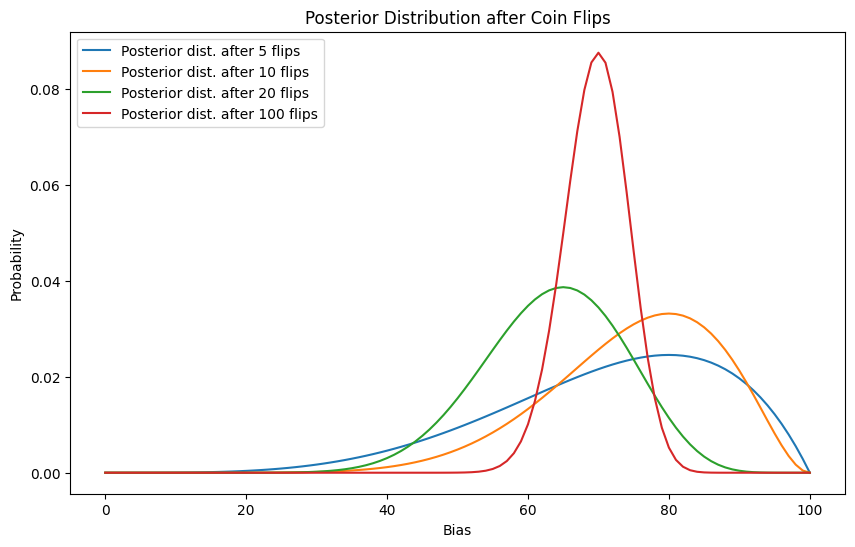

In [39]:
plt.figure(figsize=(10, 6))
for i, n in enumerate([5, 10, 20, 100]):
    # TODO: Plot posterior distribution after 5, 10, 20 and 100 flips
    plt.plot(posteriors[n-1], label = f'Posterior dist. after {n} flips')
    
plt.title('Posterior Distribution after Coin Flips')
plt.xlabel('Bias')
plt.ylabel('Probability')
plt.legend()
plt.show()

### 2.5 AI Analysis (if used)

#### Prompt(s):

#### Explanation / Changes made:

## 2.6 Discuss

**Task:**

1. [1 pt] How does the prior influence the model in early iterations (with little data) versus later iterations (with more data)?

**Ans:**

The prior is entirely flat, but after each iteration, the posterior evolves to peak around 0.7, which is the true $p$ value.

2. [2 pts] Should you take the bet with Steve? Why or why not. Include reasoning drawn from 2.5

**Ans:**

### 2.6 AI Analysis (if used)

#### Prompt(s):

#### Explanation / Changes made:


## 3 Intro: Poisson Likelihood + Gamma Prior -> Gamma Posterior

### Setup
Assume we have $X_1, X_2, \dots, X_n$ independent and identically distributed (i.i.d) Poisson distribution. So, 

$$X_i \sim \text{Pois}(\lambda) \text{ for all } i.$$

$x_i$ is a realization of $X_i$. You can imagine $x_i$ as counting the number of telephone calls in day $i$, which follows a Poisson distribution, where $\lambda$ is the (unknown) average number of phone calls a day.

**Goal:** We want to conduct Bayesian inference on the data $x_1, \dots, x_n$ in order to infer the unknown parameter $\lambda$.

### a. Likelihood $p(x | \lambda)$
The probability mass function of Poisson is 

$$p(x| \lambda) = \frac{\lambda^{x}e^{-\lambda}}{x!}.$$

Therefore, by i.i.d. assumption, the joint likelihood of all the $n$ pieces of data will be the product of the pmf, simplified for you here
$$p (x_1, \dots, x_n) = \frac{\lambda^{x_1 + \dots  + x_n} e^{-n\lambda}}{x_1! \dots x_n!}.$$

### b. Prior $p(\lambda)$
Remember, we don't know what $\lambda$ is, so we will treat it as a random variable $\Lambda$. Magically, if we let $\Lambda$ follow a Gamma distribution, we get a nice posterior, so we will do just that. Now, the pdf of Gamma(shape=$\alpha$, rate=$\beta$) is

$$p(\lambda) = \frac{\beta^\alpha}{\Gamma(\alpha)}\lambda^{\alpha-1}e^{-\beta\lambda},$$

where $\Gamma(\cdot)$ is the gamma function. When you choose your prior, **choose any $\alpha >0, \beta>0$ that is suitable for the prior knowledge you have about the desired parameter**. See section notes if you feel unfamiliar about it.

_Do not be intimidated by this crazy formula! It will be very friendly to us in the end of the calculation. Question: doesn't the gamma distribution look kind of similar to the Poisson distribution? This may give us a sense that the posterior will be nice! :)_

### c. Posterior $p(\lambda | x)$
We're almost done. 

Recall: The formula of the posterior distribution is
$$
p(\lambda | x) = \frac{p(x|\lambda)p(\lambda)}{\int_{\lambda} \ p(x|\lambda)p(\lambda) \ d\lambda} = \frac{\text{likelihood} \cdot \text{prior}}{\text{normalizing constant}}.
$$
We will skip the algebra and just tell you that 
$$
p(\lambda | x) = \frac{\lambda^{{\color{red}x_1 + \dots + x_n + \alpha}- 1} e^{-({\color{red}{n + \beta}})\lambda}}{\text{normalizing constant}}.
$$
The normalizing constant is not very important, the **MAIN TAKEAWAY IS THAT THE POSTERIOR IS ALSO DISTRIBUTED GAMMA! :)** In fact, the posterior is 
$$
\text{Gamma}(x_1 + \dots + x_n + \alpha, \ n + \beta).
$$

### Summary
- Likelihood $p(x | \lambda) \sim \text{Pois}(\lambda)$
- Prior $p(\lambda) \sim \text{Gamma}(\alpha, \beta)$
- Posterior $p(\lambda | x)\sim \text{Gamma}(x_1 + \dots + x_n + \alpha, \ n + \beta)$

With this, you are ready to tackle the first problem. Run the following code cell. Let the full data ($n=30$) be
$$
x = [ 8,  8,  7, 11, 10,  6,  7, 11,  5, 12,  8,  7,  8,  8, 11,  4,  3,
        9,  9,  4,  7,  7,  9, 12,  8,  9, 10,  9,  8,  8]
$$
Define:
- `x`, the original 30 data points
- `x_short`, only the first 3 data points

In [40]:
import scipy.stats as stats

x = [ 8,  8,  7, 11, 10,  6,  7, 11,  5, 12,  8,  7,  8,  8, 11,  4,  3,  9,  9,  4,  7,  7,  9, 12,  8,  9, 10,  9,  8,  8]
n = len(x)
print('n:', n, '\nmean:', np.mean(x))
x_short = x[:3]
n_short = len(x_short)
print('x_short:', x_short)
print('n_short:', n_short, '\nmean x_short:', np.round(np.mean(x_short),2))

n: 30 
mean: 8.1
x_short: [8, 8, 7]
n_short: 3 
mean x_short: 7.67


## 3.1 Prior

Recall the story about inferring the average number of phone calls. First, we want to create a (peaked) prior that reflects our belief about what the data (number of phone calls) is.     

Suppose Mrs. Morgan said, "From my experience and memory, I think the average number of phone calls every day is 4. Most of the time (like 95% of the time), it's between 2 to 6 calls every day."


**Task:**
1. [2 pts] Define appropriate `alpha_prior1`, `beta_prior1` to obtain a suitable prior gamma($\alpha, \beta$) with appropriate mean and variance. 
Hint: for $\text{Gamma}(\alpha, \beta)$, mean = $\frac{\alpha}{\beta}$ and variance = $\frac{\alpha}{\beta^2}$. 
2. [2 pts] Compute ```prior1```, which is the pdf of gamma($\alpha, \beta$) evaluated at multiple $\lambda$. Make sure you read the scipy documentation correctly and input the correct arguments (rate and scale are reciprocals of each other!).
3. [2 pts] Plot the density of the prior.

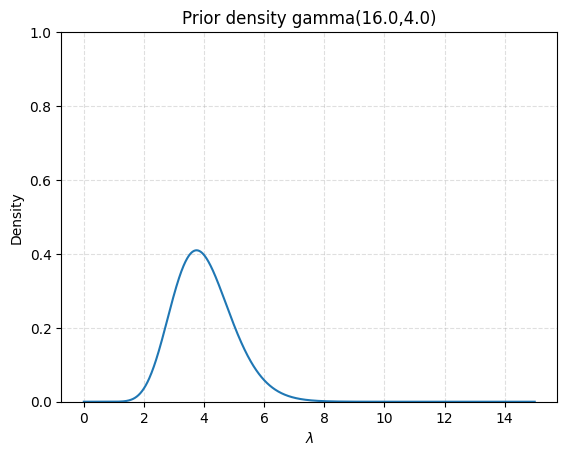

In [42]:
import scipy

# TODO alpha and beta
beta_prior1 = 4
alpha_prior1 = 16
# this is because the interval is [2,6], which is 2 sd's from the mean
# so we set alpha / beta = 4 and sqrt(alpha / beta^2) = 2/2 

lamb = np.linspace(0, 15, 1000)
# TODO prior1
prior1 = scipy.stats.gamma.pdf(lamb, alpha_prior1, scale = 1 / beta_prior1)

# TODO plot

plt.plot(lamb, prior1)


plt.title(f'Prior density gamma({alpha_prior1:.1f},{beta_prior1:.1f})')
plt.xlabel(r'$\lambda$')
plt.ylabel(r'Density')
plt.grid(alpha=.4, linestyle='--')
plt.ylim([0,1])
plt.show()

### 3.1 AI Analysis (if used)

#### Prompt(s):

#### Explanation / Changes made:

## 3.2 Posterior parameters
Let the posterior parameters be
- ```alpha_post1```, be the posterior shape for full data ```x```.
- ```beta_post1```, be the posterior rate for full data ```x```.
- ```alpha_post1_short```, be the posterior shape for short data ```x_short```.
- ```beta_post1_short```, be the posterior rate for short data ```x_short```.

**Task:**

[2 pts] Define ```alpha_post1```, ```beta_post1```, ```alpha_post1_short```, and ```beta_post1_short``` using the formula in the introduction.

In [47]:
len(x)

30

In [48]:
# TODO alpha, beta
alpha_post1 = alpha_prior1 + sum(x)
beta_post1 = beta_prior1 + n

alpha_post1_short = alpha_prior1 + sum(x_short)
beta_post1_short = beta_prior1 + n_short


### 3.2 AI Analysis (if used)

#### Prompt(s):

#### Explanation / Changes made:

## 3.3 Posterior plot

**Task:**

1. [2 pts] Define ```posterior1``` and ```posterior1_short```, the respective pdf of the posteriors. Use the same horizontal axis ```lamb``` from previous parts.
2. [2 pts] Plot the three densities (prior1, posterior1, posterior1_short) on the same figure.

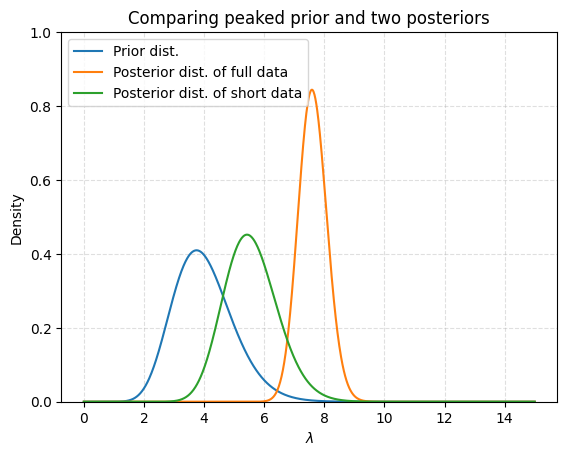

In [49]:
# TODO posterior densities
posterior1 = scipy.stats.gamma.pdf(lamb, alpha_post1, scale = 1 / beta_post1)
posterior1_short = scipy.stats.gamma.pdf(lamb, alpha_post1_short, scale = 1 / beta_post1_short)

# TODO plot

plt.plot(lamb, prior1, label = 'Prior dist.')
plt.plot(lamb, posterior1, label = 'Posterior dist. of full data')
plt.plot(lamb, posterior1_short, label = 'Posterior dist. of short data')

plt.title(f'Comparing peaked prior and two posteriors')
plt.xlabel(r'$\lambda$')
plt.ylabel(r'Density')
plt.grid(alpha=.4, linestyle='--')
plt.legend()
plt.ylim([0,1])
plt.show()

### 3.3 AI Analysis (if used)

#### Prompt(s):

#### Explanation / Changes made:

## 3.4 Peaked MAP
**Task:**

[2 pts] Compute the MAP estimator for both posteriors, storing it as ```lamb_MAP1``` and ```lamb_MAP1_short```. 


In [52]:
# TODO MAP
lamb_MAP1 = lamb[np.argmax(posterior1)]
lamb_MAP1_short = lamb[np.argmax(posterior1_short)]

print('lamb_MAP1      :', np.round(lamb_MAP1,3))
print('lamb_MAP1_short:', np.round(lamb_MAP1_short,3))

lamb_MAP1      : 7.583
lamb_MAP1_short: 5.435


### 3.4 AI Analysis (if used)

#### Prompt(s):

#### Explanation / Changes made:

## 3.5 Discuss MAP
**Task:**

[2 pt] What do you observe about the MAP estimator for the full data and short data? Which is "closer" to the prior? Give an explanation for your observations.

**Ans:** 

The MAP estimator for the full data is larger than that of the short data. This is because the expression $\frac{\alpha}{\beta}$ has grown significantly in the numerator by including the full dataset of $\sum_i x_i$. 

The short data MAP is closer to the prior because not all of the data has been included, so the data does not outweigh the contribution of the prior yet. In math terms, the location and scale of the gamma parameters have not been affected much.

### 3.5 AI Analysis (if used)

#### Prompt(s):

#### Explanation / Changes made: